**Import Necessary Modules**

We start by importing the necessary modules.

In [1]:
import astropy.units as u
import matplotlib.colors as mcolors
import numpy as np
import torch
from matplotlib import pyplot as plt
from phringe.core.scene import Scene
from phringe.core.sources.exozodi import Exozodi
from phringe.core.sources.local_zodi import LocalZodi
from phringe.core.sources.planet import Planet
from phringe.core.sources.star import Star
from phringe.io.sed_loader import SEDLoader

from lifesimmc.lib.instrument import InstrumentalNoise
from lifesimmc.presets.single_epoch_observation.single_epoch_observation import SingleEpochObservation

**Define Astrophysical Scene**

Next we define the astrophysical scene, consisting of a star, a planet, an exozodi, and the local zodi.

In [2]:
scene = Scene()

# Create star
star = Star(
    name='Sun Twin',
    distance='10 pc',
    mass='1 Msun',
    radius='1 Rsun',
    temperature='5778 K',
    right_ascension='10 hourangle',
    declination='45 deg',
)

# Create planet
earth_twin = Planet(
    name='Earth Twin',
    propagate_orbit=False,
    sed_loader=SEDLoader(
        path_to_file='../_static/psg_earth_spectrum.txt',
        sed_units='W/sr/m2/um',  # Alternatively: u.W / u.sr / u.m**2 / u.um
        wavelength_units='um',  # Alternatively: u.um
    ),
    mass='1 Mearth',
    radius='1 Rearth',
    temperature='254 K',
    semi_major_axis='1 au',
    eccentricity=0.,
    inclination='180 deg',
    raan='90 deg',
    argument_of_periapsis='0 deg',
    true_anomaly='45 deg',
)

# Create local zodi
local_zodi = LocalZodi()

# Create exozodi
exozodi = Exozodi(level=3)

# Add sources to scene
scene.add_source(star)
scene.add_source(local_zodi)
scene.add_source(exozodi)
scene.add_source(earth_twin)

Note that to use auto-generated blackbody spectra instead of a user-provided SED you can simply set `sed_loader=None` when creating the planet.

**Create Single-Epoch Observation Preset**

Then we create a single-epoch observation preset object, adding the scene and defining several other parameters, and run it.
This will run the data pipeline in the back and generate and process the data for us. For a list of all configurable parameters have a look at the [SingleEpochObservation class documentation](../source/presets/seo.rst).


In [3]:
seo = SingleEpochObservation(
    scene=scene,
    total_integration_time=1 * u.d,
    num_reps=1,
    spectral_resolving_power=20,
    instrumental_noise=InstrumentalNoise.OPTIMISTIC,
    device=torch.device('cpu'),
    grid_size=20,  # Better use at least 40
)

seo.run()

/Users/philipp/Desktop/LIFEsimMC/.venv/lib/python3.11/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Loading setup...
Done


Done
Generating templates...
Done
Applying ZCA whitening...
Done


Note that here we have set `num_reps=1`. Setting it to a number larger than 1 will run the same observation multiple times, allowing us to take the means of the results for a more robust interpretation.

**Get Detection Significance**

We can directly get an estimate of the detection significance of the injected planet through the Neyman-Pearson test.

In [4]:
det_sig = seo.get_detection_significance()

det_sig = det_sig.mean()  # Here the mean is taken over only 1 repetition

print(f"Detection significance: {det_sig:.1f} sigma")

Performing Neyman-Pearson test...
Done
Detection significance: 26.9 sigma


**Extract Spectral Energy Distribution (SED)**

We can now extract the SED of the planet from the simulated observation.

In [5]:
# Specify output units for SED and wavelengths
sed_units_out = 'ph/s/m2/um'
wl_units_out = 'um'

# Extract SED estimate and associated standard deviation and covariance
sed, std, cov = seo.extract_sed(units=sed_units_out)

# For plotting the SED we take the values from the first repetition rather than the mean
sed = sed[0]

# Take means (here only 1 repetition)
std = std.mean(axis=0)
cov = cov.mean(axis=0)

# Get the instrument wavelength bins and the input (true) planet SED
wl = seo.get_wavelength_bin_centers(units=wl_units_out)
sed_true = seo.get_input_sed(units=sed_units_out)

Done


Finally, we plot the simulated measurement:

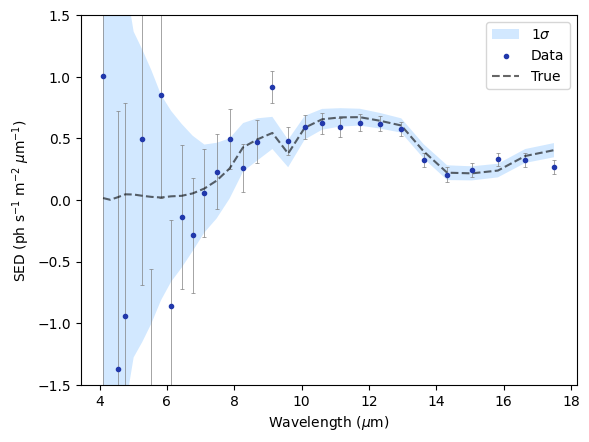

In [6]:
yerr = np.stack([std, std])
fill_bottom = np.array(sed_true) - np.array(std)
fill_top = np.array(sed_true) + np.array(std)

plt.errorbar(wl, sed, yerr=yerr, fmt='none', ecolor='gray', zorder=1, capsize=1.5, capthick=0.5, linewidth=0.5)
plt.fill_between(wl, fill_bottom, fill_top, color='dodgerblue', lw=0, alpha=0.2, label='1$\sigma$', zorder=0)
plt.scatter(wl, sed, label='Data', color="xkcd:sapphire", zorder=2, marker='.')
plt.plot(wl, sed_true, label='True', linestyle='dashed', color='black', alpha=0.6, zorder=1)
plt.ylabel('SED (ph s$^{-1}$ m$^{-2}$ $\mu$m$^{-1}$)')
plt.xlabel('Wavelength ($\mu$m)')
plt.ylim(-1.5, 1.5)
plt.legend()
plt.show()

Additionally, we can investigate the estimated covariance matrix:

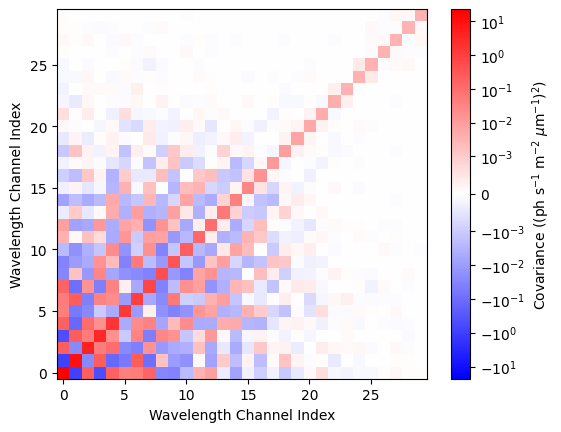

In [7]:
plt.imshow(cov, origin='lower', cmap='bwr',
           norm=mcolors.SymLogNorm(linthresh=1e-3, vmin=-np.max(cov), vmax=np.max(cov)))
plt.xlabel('Wavelength Channel Index')
plt.ylabel('Wavelength Channel Index')
plt.colorbar(label='Covariance ((ph s$^{-1}$ m$^{-2}$ $\mu$m$^{-1}$)$^2$)')
plt.show()


**Matched Filter Map**

For a visualization of the data we can plot the matched filter map, which we create by comparing the data to a set of planetary templates.

Calculating correlation map...
Done


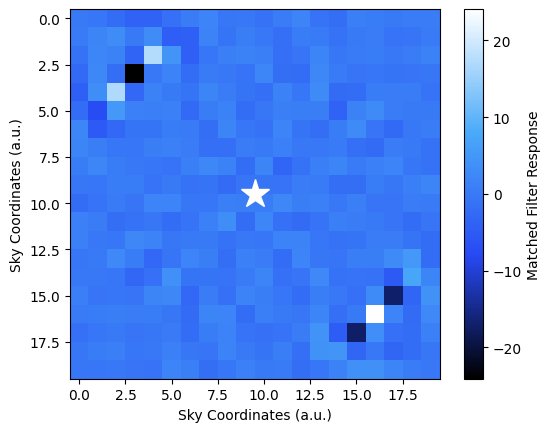

In [8]:
map = seo.get_matched_filter()

# Take the mean over all repetitions
map = map.mean(axis=0)

size = map.shape[1]
center_x, center_y = size / 2, size / 2
import matplotlib.colors as mcolors

hex_colors = ['#000000', '#2749f4', '#4aaaf9', '#FFFFFF']  # Example: red, green, blue
rgb_colors = [mcolors.hex2color(c) for c in hex_colors]
cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", rgb_colors, N=256)

plt.imshow(map, cmap=cmap)
plt.plot(center_x - 0.5, center_y - 0.5, marker='*', markersize=21, color='white')
plt.xlabel('Sky Coordinates (a.u.)')
plt.ylabel('Sky Coordinates (a.u.)')
plt.colorbar(label='Matched Filter Response')
plt.show()